# Entraînement de Modèle de Prévision des Ventes

Ce notebook a pour objectif de préparer les données pour une analyse de séries temporelles et d'entraîner un modèle de prévision.

## Étapes :
1. Chargement des données traitées.
2. Agrégation temporelle (par semaine/mois).
3. Analyse de la série temporelle (tendance, saisonnalité).
4. Entraînement d'un modèle (Prophet ou Random Forest).
5. Évaluation des performances.


## 1. Configuration et Chargement


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration graphiques
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Définition des chemins
try:
    BASE_DIR = os.path.dirname(os.path.abspath(os.path.dirname(__file__)))
except NameError:
    BASE_DIR = "/Users/amaury/olist-sales-forecast"

PROCESSED_DATA_PATH = os.path.join(BASE_DIR, "data", "processed", "olist_full_dataset.csv")


In [2]:
# Chargement des données
if not os.path.exists(PROCESSED_DATA_PATH):
    raise FileNotFoundError(f"Le fichier {PROCESSED_DATA_PATH} n'existe pas. Veuillez exécuter l'EDA d'abord pour le générer.")

df = pd.read_csv(PROCESSED_DATA_PATH)
print("Données chargées :", df.shape)


Données chargées : (118310, 43)


## 2. Préparation des Données (Time Series)

Nous allons agréger les ventes par **Semaine** pour avoir une série temporelle stable.


In [3]:
# Conversion des dates
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Agrégation par semaine (W = Weekly)
# On s'intéresse au Chiffre d'Affaires (payment_value ou price + freight) et au Nombre de Commandes
df_weekly = df.set_index('order_purchase_timestamp').resample('W').agg({
    'order_id': 'count',
    'payment_value': 'sum'
}).rename(columns={'order_id': 'order_count', 'payment_value': 'total_revenue'})

# Filtrage des données incomplètes (souvent la dernière semaine est incomplète)
df_weekly = df_weekly.iloc[:-1]

print("Aperçu des données hebdomadaires :")
print(df_weekly.head())


Aperçu des données hebdomadaires :
                          order_count  total_revenue
order_purchase_timestamp                            
2016-09-04                          2         272.46
2016-09-11                          1          75.06
2016-09-18                          3           0.00
2016-09-25                          0           0.00
2016-10-02                          1         109.34


## 3. Visualisation de la Série Temporelle


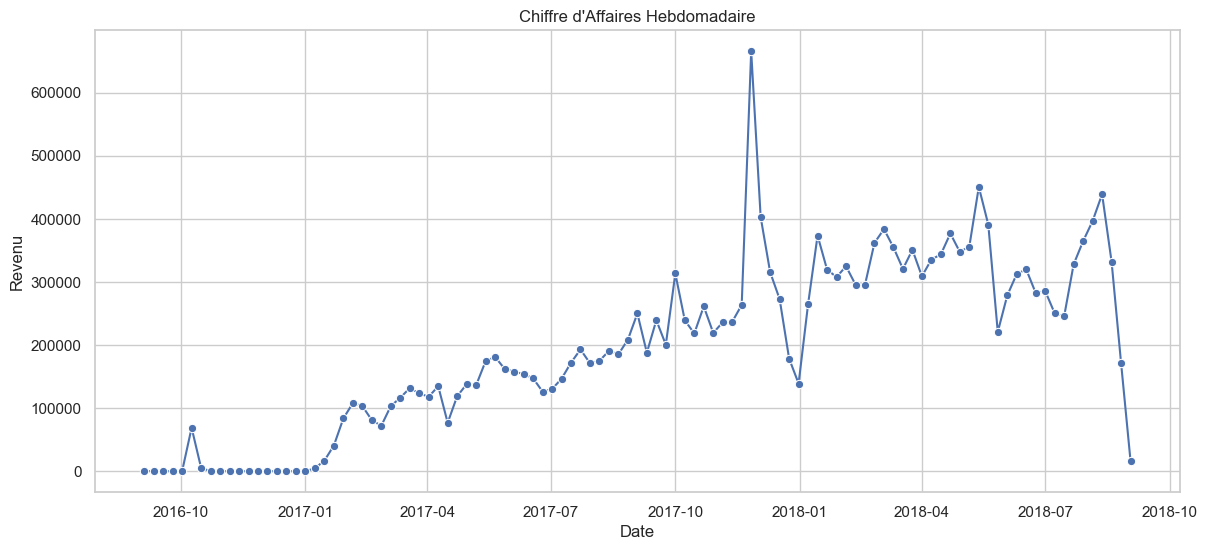

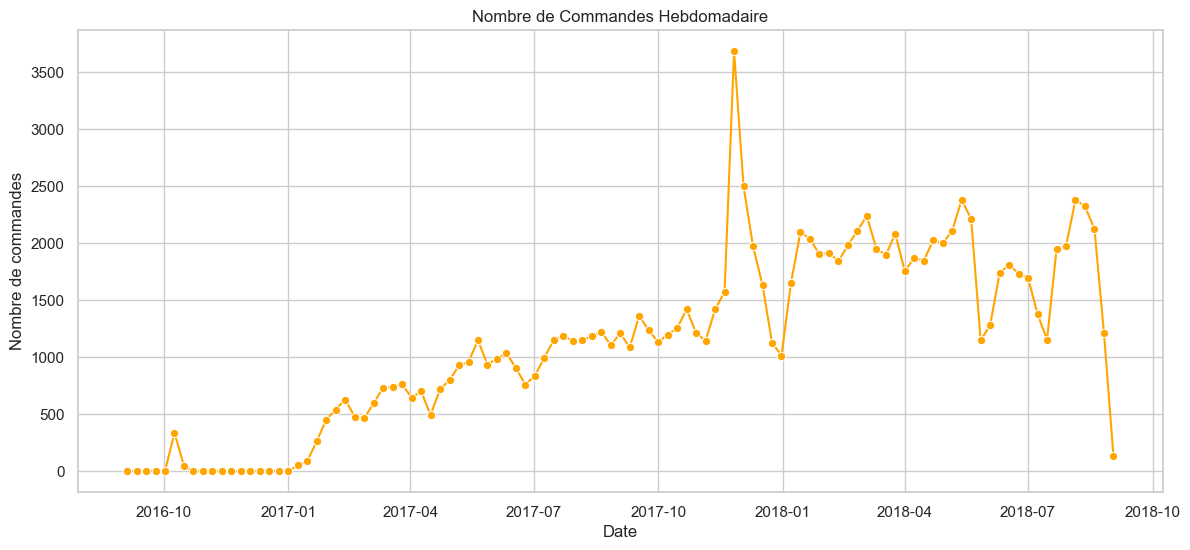

In [4]:
# Graphique des ventes
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_weekly, x=df_weekly.index, y='total_revenue', marker='o')
plt.title("Chiffre d'Affaires Hebdomadaire")
plt.xlabel("Date")
plt.ylabel("Revenu")
plt.show()

# Graphique du nombre de commandes
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_weekly, x=df_weekly.index, y='order_count', marker='o', color='orange')
plt.title("Nombre de Commandes Hebdomadaire")
plt.xlabel("Date")
plt.ylabel("Nombre de commandes")
plt.show()


## 4. Entraînement du Modèle

Nous allons utiliser **Prophet** si disponible, sinon un modèle de régression **Random Forest** avec des features temporelles.


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Préparation pour le Machine Learning classique (Feature Engineering)
# Création de features basées sur le temps
df_model = df_weekly.copy()
df_model['week_of_year'] = df_model.index.isocalendar().week
df_model['month'] = df_model.index.month
df_model['year'] = df_model.index.year

# Lag features (valeurs passées)
df_model['revenue_lag_1'] = df_model['total_revenue'].shift(1)
df_model['revenue_lag_4'] = df_model['total_revenue'].shift(4) # Mois dernier
df_model.dropna(inplace=True)

# Séparation Train / Test (80% train, 20% test)
train_size = int(len(df_model) * 0.8)
train, test = df_model.iloc[:train_size], df_model.iloc[train_size:]

X_train = train[['week_of_year', 'month', 'year', 'revenue_lag_1', 'revenue_lag_4']]
y_train = train['total_revenue']
X_test = test[['week_of_year', 'month', 'year', 'revenue_lag_1', 'revenue_lag_4']]
y_test = test['total_revenue']

print(f"Train size: {len(train)}, Test size: {len(test)}")


Train size: 80, Test size: 21


In [6]:
# Entraînement (Random Forest Regressor)
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prédictions
predictions = model.predict(X_test)


In [7]:
# Tentative d'utilisation de Prophet (Optionnel)
use_prophet = False
try:
    from prophet import Prophet
    use_prophet = True
    print("Prophet est installé. Entraînement du modèle Prophet...")
    
    # Formatage pour Prophet
    # Utiliser df_model pour avoir exactement les mêmes lignes (après dropna)
    df_prophet = df_model.reset_index()[['order_purchase_timestamp', 'total_revenue']]
    df_prophet.columns = ['ds', 'y']
    
    # Split
    train_prophet = df_prophet.iloc[:train_size]
    test_prophet = df_prophet.iloc[train_size:]
    
    # Modéle
    m = Prophet(weekly_seasonality=True, yearly_seasonality=True)
    m.fit(train_prophet)
    
    # Prédiction
    future = m.make_future_dataframe(periods=len(test_prophet), freq='W')
    forecast = m.predict(future)
    
    # Récupération des prédictions pour le test set
    prophet_preds = forecast.iloc[-len(test_prophet):]['yhat'].values
    
except ImportError:
    print("Prophet n'est pas installé. On continue avec Random Forest uniquement.")


/Users/amaury/olist-sales-forecast/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
23:44:34 - cmdstanpy - INFO - Chain [1] start processing
23:44:34 - cmdstanpy - INFO - Chain [1] done processing


Prophet est installé. Entraînement du modèle Prophet...


## 5. Évaluation des Performances


In [8]:
# Calcul des métriques
mae_rf = mean_absolute_error(y_test, predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Random Forest - MAE: {mae_rf:.2f}")
print(f"Random Forest - RMSE: {rmse_rf:.2f}")

if use_prophet:
    mae_prophet = mean_absolute_error(test_prophet['y'], prophet_preds)
    print(f"Prophet - MAE: {mae_prophet:.2f}")


Random Forest - MAE: 58865.64
Random Forest - RMSE: 78925.67
Prophet - MAE: 113016.49


## 6. Visualisation des Prédictions


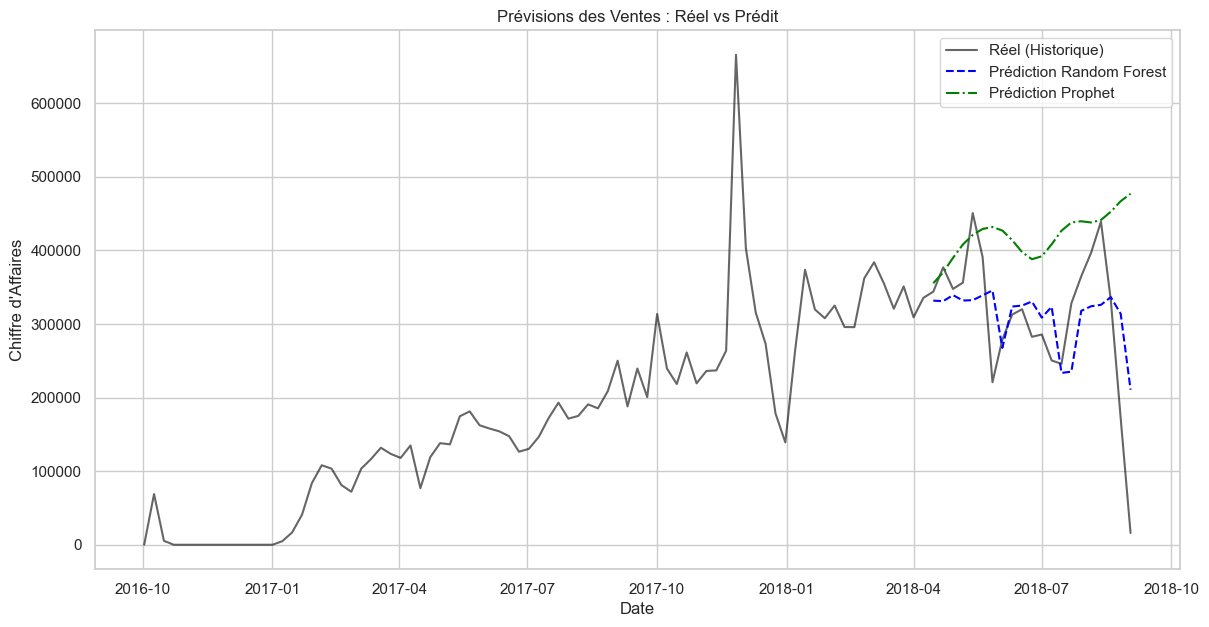

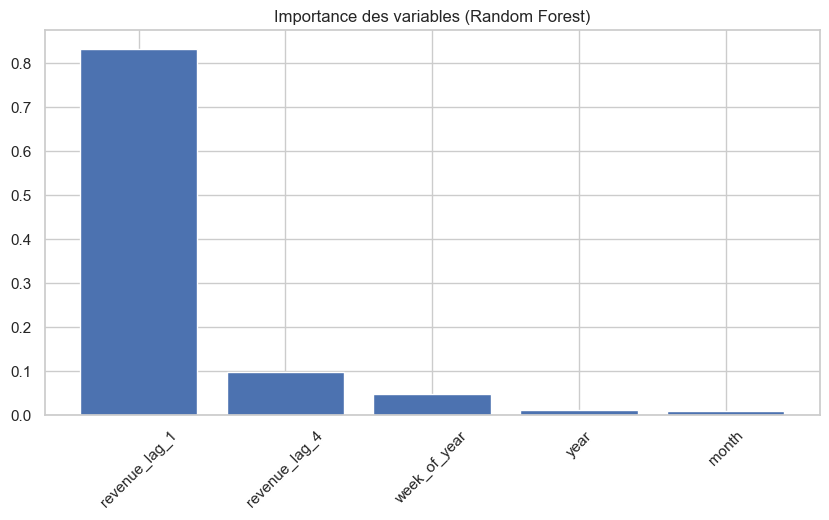

In [9]:
plt.figure(figsize=(14, 7))

# Données réelles
plt.plot(df_model.index, df_model['total_revenue'], label='Réel (Historique)', color='black', alpha=0.6)

# Prédictions Random Forest
plt.plot(test.index, predictions, label='Prédiction Random Forest', color='blue', linestyle='--')

# Prédictions Prophet
if use_prophet:
    plt.plot(test.index, prophet_preds, label='Prédiction Prophet', color='green', linestyle='-.')

plt.title("Prévisions des Ventes : Réel vs Prédit")
plt.xlabel("Date")
plt.ylabel("Chiffre d'Affaires")
plt.legend()
plt.show()

# Feature Importance (RF)
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

plt.figure(figsize=(10, 5))
plt.title("Importance des variables (Random Forest)")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), features[indices], rotation=45)
plt.show()
